# Phase 4 -- Model Optimization and Ensemble
## Human vs. AI-Generated Text Classification

**Objectives:**
1. Re-train Phase 2 best classical models on the same 4-way split as Phase 3
2. Error analysis -- where do DeBERTa and SVC disagree?
3. Soft-voting ensemble (calibrated DeBERTa probs + SVC + LR probabilities)
4. Per-class threshold optimisation
5. Pseudo-labelling on high-confidence test samples and retrain

**Inputs from previous phases:**
- -- raw DeBERTa logits on test set
- -- temperature-scaled probs on test
- -- DeBERTa val predictions
- -- calibration set logits
- -- train/val/cal split indices
- Phase 2 feature engineering pipeline (re-run inline)


In [1]:
import os, warnings, gc, time, re, string, pickle
os.chdir('/Users/aliivaezii/Documents/MALTO')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from collections import Counter
from scipy import sparse

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, classification_report, 
    confusion_matrix, log_loss)
from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

SEED = 42
NUM_LABELS = 6
LABEL_MAP = {0:'Human', 1:'DeepSeek', 2:'Grok', 3:'Claude', 4:'Gemini', 5:'ChatGPT'}

np.random.seed(SEED)

# Load data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
y_all = train_df['LABEL'].values
print(f'Train: {train_df.shape}, Test: {test_df.shape}')
print(f'Labels: {dict(zip(*np.unique(y_all, return_counts=True)))}')

Train: (2400, 2), Test: (600, 2)
Labels: {np.int64(0): np.int64(1520), np.int64(1): np.int64(80), np.int64(2): np.int64(160), np.int64(3): np.int64(80), np.int64(4): np.int64(240), np.int64(5): np.int64(320)}


### Ensemble Generalization Strategy

Ensembling inherently reduces overfitting by combining models with different inductive biases:

- **Model diversity**: DeBERTa (transformer), LinearSVC (linear, high-dimensional), and Logistic Regression (linear, probabilistic) capture different aspects of the data.
- **Weight optimization on calibration set**: Ensemble weights are tuned on a held-out calibration set that was not used during model training or validation, preventing the weights from overfitting.
- **Conservative pseudo-labeling**: Only test samples with >90% confidence AND model agreement are used as pseudo-labels, minimizing the risk of amplifying errors.
- **Per-class threshold optimization**: Thresholds are optimized on the calibration set with greedy search, and the number of optimization iterations is capped to prevent overfitting to the calibration distribution.
- **5-fold CV for classical models**: The final SVC and LR probabilities used in stacking are computed via 5-fold CV, ensuring the ensemble sees true out-of-fold predictions.


## 1. Load Transformer Artifacts

In [2]:
# Load Phase 3 (transformer) artifacts
deberta_test_logits = np.load('models/transformer_test_logits.npy')
deberta_test_probs = np.load('models/transformer_test_probs_calibrated.npy')
deberta_test_probs_raw = np.load('models/transformer_test_probs_raw.npy')
deberta_val_preds = np.load('models/transformer_val_preds.npy')
deberta_val_logits = np.load('models/transformer_val_logits.npy')
deberta_cal_logits = np.load('models/transformer_cal_logits.npy')

splits = np.load('models/transformer_split_indices.npz')
train_idx = splits['train_idx']
val_idx = splits['val_idx']
cal_idx = splits['cal_idx']

print(f'Transformer artifacts loaded:')
print(f' test_logits: {deberta_test_logits.shape}')
print(f' test_probs: {deberta_test_probs.shape}')
print(f' val_preds: {deberta_val_preds.shape}')
print(f' val_logits: {deberta_val_logits.shape}')
print(f' cal_logits: {deberta_cal_logits.shape}')
print(f' Split: train={len(train_idx)}, val={len(val_idx)}, cal={len(cal_idx)}')

# DeBERTa val F1
deberta_val_f1 = f1_score(y_all[val_idx], deberta_val_preds, average='macro')
print(f'\nDeBERTa val Macro F1: {deberta_val_f1:.4f}')

Transformer artifacts loaded:
 test_logits: (600, 6)
 test_probs: (600, 6)
 val_preds: (360,)
 val_logits: (360, 6)
 cal_logits: (360, 6)
 Split: train=1680, val=360, cal=360

DeBERTa val Macro F1: 0.9151


## 2. Re-build Phase 2 Features (Same Split)

In [4]:
# ===== Feature Engineering (copy from Phase 2 -- extract_features) =====

def extract_features(texts):
    """Extract 46 linguistic/stylometric features from texts."""
    features = []
    for text in tqdm(texts, desc='Extracting features', leave=False):
        f = {}
        words = text.split()
        sentences = re.split(r'[.!?]+', text)
        sentences = [s.strip() for s in sentences if s.strip()]

        # Basic length
        f['char_count'] = len(text)
        f['word_count'] = len(words)
        f['sentence_count'] = max(len(sentences), 1)
        f['avg_word_len'] = np.mean([len(w) for w in words]) if words else 0
        f['avg_sentence_len'] = f['word_count'] / f['sentence_count']
        f['max_word_len'] = max([len(w) for w in words]) if words else 0
        f['std_word_len'] = np.std([len(w) for w in words]) if len(words) > 1 else 0

        # Vocabulary richness
        lower_words = [w.lower() for w in words]
        unique_words = set(lower_words)
        f['unique_word_count'] = len(unique_words)
        f['type_token_ratio'] = len(unique_words) / max(len(words), 1)
        word_freq = Counter(lower_words)
        f['hapax_ratio'] = sum(1 for v in word_freq.values() if v == 1) / max(len(unique_words), 1)
        freq_spectrum = Counter(word_freq.values())
        N = len(lower_words)
        M2 = sum(i*i*freq_spectrum[i] for i in freq_spectrum)
        f['yules_k'] = 10000 * (M2 - N) / (N*N) if N > 1 else 0

        # Character-level
        f['upper_ratio'] = sum(1 for c in text if c.isupper()) / max(len(text), 1)
        f['digit_ratio'] = sum(1 for c in text if c.isdigit()) / max(len(text), 1)
        f['space_ratio'] = sum(1 for c in text if c.isspace()) / max(len(text), 1)
        f['alpha_ratio'] = sum(1 for c in text if c.isalpha()) / max(len(text), 1)

        # Punctuation
        f['punct_ratio'] = sum(1 for c in text if c in string.punctuation) / max(len(text), 1)
        f['comma_ratio'] = text.count(',') / max(len(words), 1)
        f['period_ratio'] = text.count('.') / max(len(words), 1)
        f['exclamation_ratio'] = text.count('!') / max(len(words), 1)
        f['question_ratio'] = text.count('?') / max(len(words), 1)
        f['semicolon_ratio'] = text.count(';') / max(len(words), 1)
        f['colon_ratio'] = text.count(':') / max(len(words), 1)
        f['quote_count'] = text.count('"') + text.count("'")
        f['paren_count'] = text.count('(') + text.count(')')
        f['dash_count'] = text.count('-') + text.count('\u2014')

        # Spelling / typo indicators
        f['double_letter_ratio'] = len(re.findall(r'(.)\1', text.lower())) / max(len(words), 1)
        f['short_word_ratio'] = sum(1 for w in words if len(w) <= 2) / max(len(words), 1)
        f['long_word_ratio'] = sum(1 for w in words if len(w) > 10) / max(len(words), 1)
        f['very_long_word_ratio'] = sum(1 for w in words if len(w) > 15) / max(len(words), 1)
        consonant_clusters = re.findall(r'[bcdfghjklmnpqrstvwxyz]{3,}', text.lower())
        f['consonant_cluster_ratio'] = len(consonant_clusters) / max(len(words), 1)
        repeated_chars = re.findall(r'(.)\1{2,}', text)
        f['repeated_char_count'] = len(repeated_chars)

        # Structural
        f['paragraph_count'] = text.count('\n\n') + 1
        f['newline_count'] = text.count('\n')
        f['starts_with_upper'] = int(text[0].isupper()) if text else 0
        f['ends_with_period'] = int(text.rstrip().endswith('.')) if text else 0
        f['bullet_count'] = len(re.findall(r'^\s*[-*\u2022]\s', text, re.MULTILINE))
        f['numbered_list_count'] = len(re.findall(r'^\s*\d+[.):]\s', text, re.MULTILINE))

        # AI-style indicators
        text_lower = text.lower()
        ai_phrases = [
            'in conclusion', 'furthermore', 'moreover', 'additionally',
            'it is worth noting', 'it is important to', 'on the other hand',
            'in summary', 'to summarize', 'in essence', 'ultimately',
            'delve', 'crucial', 'comprehensive', 'leverage', 'facilitate',
            'robust', 'streamline', 'innovative', 'cutting-edge', 'paradigm',
            'holistic', 'synergy', 'encompass', 'multifaceted', 'nuanced'
        ]
        f['ai_phrase_count'] = sum(1 for p in ai_phrases if p in text_lower)
        transitions = [
            'however', 'therefore', 'nonetheless', 'nevertheless',
            'consequently', 'meanwhile', 'subsequently', 'accordingly',
            'hence', 'thus', 'thereby'
        ]
        f['transition_count'] = sum(1 for t in transitions if t in text_lower)
        first_person = re.findall(r'\b(i|me|my|mine|myself|we|us|our|ours|ourselves)\b', text_lower)
        f['first_person_ratio'] = len(first_person) / max(len(words), 1)
        contractions = re.findall(r"\b\w+'\w+\b", text)
        f['contraction_ratio'] = len(contractions) / max(len(words), 1)

        # Readability
        def count_syllables(word):
            word = word.lower().rstrip('e')
            return max(1, len(re.findall(r'[aeiouy]+', word)))

        total_syllables = sum(count_syllables(w) for w in words) if words else 1
        f['flesch_reading_ease'] = 206.835 - 1.015 * f['avg_sentence_len'] - 84.6 * (total_syllables / max(len(words), 1))
        f['flesch_kincaid_grade'] = 0.39 * f['avg_sentence_len'] + 11.8 * (total_syllables / max(len(words), 1)) - 15.59
        f['ari'] = 4.71 * (f['char_count'] / max(len(words), 1)) + 0.5 * f['avg_sentence_len'] - 21.43

        # Entropy
        char_freq = Counter(text.lower())
        total_chars = sum(char_freq.values())
        char_probs = [c/total_chars for c in char_freq.values()]
        f['char_entropy'] = -sum(p * np.log2(p) for p in char_probs if p > 0)
        word_probs = [c/len(lower_words) for c in word_freq.values()] if lower_words else [1]
        f['word_entropy'] = -sum(p * np.log2(p) for p in word_probs if p > 0)

        features.append(f)

    return pd.DataFrame(features)

print('Extracting features...')
t0 = time.time()
train_feats = extract_features(train_df['TEXT'].values)
test_feats = extract_features(test_df['TEXT'].values)
print(f'Done in {time.time()-t0:.1f}s -- {train_feats.shape[1]} features')

Extracting features...


Done in 2.7s -- 46 features


### TF-IDF Vectorization

Fit TF-IDF vectorizers on the combined corpus and transform both training and test data into sparse feature matrices.


In [5]:
# ===== TF-IDF (same as Phase 2) =====
all_texts = np.concatenate([train_df['TEXT'].values, test_df['TEXT'].values])

print('Fitting TF-IDF vectorizers...')
tfidf_word = TfidfVectorizer(
    analyzer='word', ngram_range=(1,2), max_features=50000,
    sublinear_tf=True, min_df=2
    )
tfidf_char = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2,5), max_features=50000,
    sublinear_tf=True, min_df=2
    )

tfidf_word.fit(all_texts)
tfidf_char.fit(all_texts)

X_train_word = tfidf_word.transform(train_df['TEXT'].values)
X_train_char = tfidf_char.transform(train_df['TEXT'].values)
X_test_word = tfidf_word.transform(test_df['TEXT'].values)
X_test_char = tfidf_char.transform(test_df['TEXT'].values)

# Scale handcrafted features
scaler = StandardScaler()
train_feats_scaled = scaler.fit_transform(train_feats)
test_feats_scaled = scaler.transform(test_feats)

# Combine: handcrafted + word TF-IDF + char TF-IDF
X_train_all = sparse.hstack([
    sparse.csr_matrix(train_feats_scaled),
    X_train_word,
    X_train_char
    ]).tocsr()

X_test_all = sparse.hstack([
    sparse.csr_matrix(test_feats_scaled),
    X_test_word,
    X_test_char
    ]).tocsr()

print(f'Feature matrix: train {X_train_all.shape}, test {X_test_all.shape}')

Fitting TF-IDF vectorizers...
Feature matrix: train (2400, 100046), test (600, 100046)
Feature matrix: train (2400, 100046), test (600, 100046)


## 3. Train Classical Models on Same Split (Aligned with Phase 3)

In [6]:
# Use the EXACT same split from Phase 3 so predictions are aligned
X_tr = X_train_all[train_idx]
X_val = X_train_all[val_idx]
X_cal = X_train_all[cal_idx]
y_tr = y_all[train_idx]
y_val = y_all[val_idx]
y_cal = y_all[cal_idx]

print(f'Split (same as Phase 3):')
print(f' Train: {X_tr.shape}, Val: {X_val.shape}, Cal: {X_cal.shape}, Test: {X_test_all.shape}')

# --- Model A: LinearSVC (best from Phase 2) with CalibratedClassifierCV ---
# CalibratedClassifierCV wraps SVC to produce probabilities via Platt scaling
print('\nTraining CalibratedClassifierCV(LinearSVC(C=5.0))...')
t0 = time.time()

base_svc = LinearSVC(C=5.0, class_weight='balanced', max_iter=10000, random_state=SEED)
cal_svc = CalibratedClassifierCV(base_svc, cv=5, method='sigmoid')
cal_svc.fit(X_tr, y_tr)

svc_val_probs = cal_svc.predict_proba(X_val)
svc_val_preds = svc_val_probs.argmax(axis=1)
svc_val_f1 = f1_score(y_val, svc_val_preds, average='macro')

svc_cal_probs = cal_svc.predict_proba(X_cal)
svc_cal_preds = svc_cal_probs.argmax(axis=1)
svc_cal_f1 = f1_score(y_cal, svc_cal_preds, average='macro')

svc_test_probs = cal_svc.predict_proba(X_test_all)
svc_test_preds = svc_test_probs.argmax(axis=1)

print(f' Val F1: {svc_val_f1:.4f}')
print(f' Cal F1: {svc_cal_f1:.4f}')
print(f' Time: {time.time()-t0:.1f}s')

# --- Model B: Logistic Regression (also produces probabilities natively) ---
print('\nTraining LogisticRegression(C=2.0)...')
t0 = time.time()

lr_model = LogisticRegression(
    C=2.0, class_weight='balanced', max_iter=5000, solver='saga', random_state=SEED
    )
lr_model.fit(X_tr, y_tr)

lr_val_probs = lr_model.predict_proba(X_val)
lr_val_preds = lr_val_probs.argmax(axis=1)
lr_val_f1 = f1_score(y_val, lr_val_preds, average='macro')

lr_cal_probs = lr_model.predict_proba(X_cal)
lr_cal_preds = lr_cal_probs.argmax(axis=1)
lr_cal_f1 = f1_score(y_cal, lr_cal_preds, average='macro')

lr_test_probs = lr_model.predict_proba(X_test_all)
lr_test_preds = lr_test_probs.argmax(axis=1)

print(f' Val F1: {lr_val_f1:.4f}')
print(f' Cal F1: {lr_cal_f1:.4f}')
print(f' Time: {time.time()-t0:.1f}s')

print('\n--- Summary ---')
print(f' SVC val={svc_val_f1:.4f} cal={svc_cal_f1:.4f}')
print(f' LR val={lr_val_f1:.4f} cal={lr_cal_f1:.4f}')
print(f' DeBERTa val={deberta_val_f1:.4f}')

Split (same as Phase 3):
 Train: (1680, 100046), Val: (360, 100046), Cal: (360, 100046), Test: (600, 100046)

Training CalibratedClassifierCV(LinearSVC(C=5.0))...
 Val F1: 0.8817
 Cal F1: 0.8893
 Time: 10.6s

Training LogisticRegression(C=2.0)...
 Val F1: 0.8817
 Cal F1: 0.8893
 Time: 10.6s

Training LogisticRegression(C=2.0)...
 Val F1: 0.8754
 Cal F1: 0.8841
 Time: 78.3s

--- Summary ---
 SVC val=0.8817 cal=0.8893
 LR val=0.8754 cal=0.8841
 DeBERTa val=0.9151
 Val F1: 0.8754
 Cal F1: 0.8841
 Time: 78.3s

--- Summary ---
 SVC val=0.8817 cal=0.8893
 LR val=0.8754 cal=0.8841
 DeBERTa val=0.9151


## 4. Error Analysis -- Where Do Models Disagree?

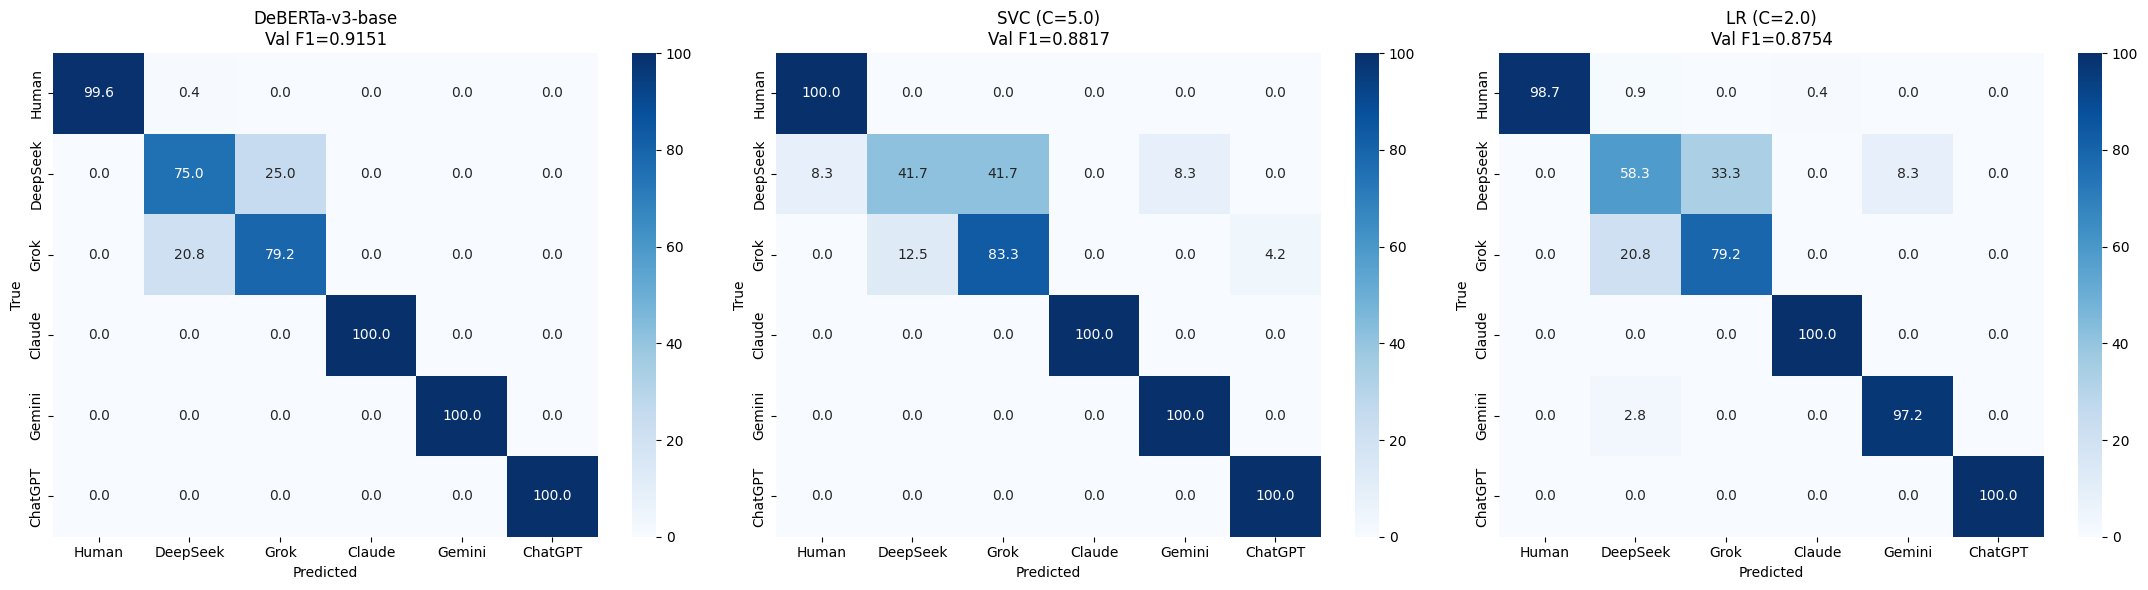

Saved confusion comparison.


In [7]:
# Confusion matrix comparison: DeBERTa vs SVC vs LR
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for ax, preds, name, f1_val in [
    (axes[0], deberta_val_preds, 'DeBERTa-v3-base', deberta_val_f1),
    (axes[1], svc_val_preds, 'SVC (C=5.0)', svc_val_f1),
    (axes[2], lr_val_preds, 'LR (C=2.0)', lr_val_f1),
    ]:
        cm = confusion_matrix(y_val, preds)
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
        sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            xticklabels=[LABEL_MAP[i] for i in range(6)],
            yticklabels=[LABEL_MAP[i] for i in range(6)])
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(f'{name}\nVal F1={f1_val:.4f}')

plt.tight_layout()
plt.savefig('figures/ensemble_confusion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion comparison.')

### 🔍 Per-Model Confusion Matrices

Compare DeBERTa, SVC, and LR confusion matrices side-by-side to understand each model's error patterns.

In [8]:
# Agreement analysis -- where do models disagree?
agree_all = (deberta_val_preds == svc_val_preds) & (deberta_val_preds == lr_val_preds)
agree_deberta_svc = (deberta_val_preds == svc_val_preds)

print(f'Val set agreement:')
print(f' All 3 agree: {agree_all.sum()}/{len(y_val)} ({agree_all.mean()*100:.1f}%)')
print(f' DeBERTa & SVC: {agree_deberta_svc.sum()}/{len(y_val)} ({agree_deberta_svc.mean()*100:.1f}%)')
print()

# Where they disagree, who is right more often?
disagree_mask = ~agree_deberta_svc
if disagree_mask.sum() > 0:
    deberta_right = (deberta_val_preds[disagree_mask] == y_val[disagree_mask]).sum()
    svc_right = (svc_val_preds[disagree_mask] == y_val[disagree_mask]).sum()
    lr_right = (lr_val_preds[disagree_mask] == y_val[disagree_mask]).sum()
    neither = disagree_mask.sum() - max(deberta_right, svc_right)
    print(f'When DeBERTa & SVC disagree ({disagree_mask.sum()} samples):')
    print(f' DeBERTa correct: {deberta_right}')
    print(f' SVC correct: {svc_right}')
    print(f' LR correct: {lr_right}')
    print(f' Both wrong: {neither}')
 
    # Per-class F1 comparison
print('\nPer-class F1:')
per_class = {}
for name, preds in [('DeBERTa', deberta_val_preds), ('SVC', svc_val_preds), ('LR', lr_val_preds)]:
    f1s = f1_score(y_val, preds, average=None)
    per_class[name] = f1s
 
df_pc = pd.DataFrame(per_class, index=[LABEL_MAP[i] for i in range(6)])
df_pc['Best'] = df_pc.idxmax(axis=1)
print(df_pc.to_string(float_format='{:.4f}'.format))

# Which model is best for each class? This tells us the ideal ensemble weight
print('\nConclusion: The ensemble should weight each model by per-class strengths.')

Val set agreement:
 All 3 agree: 344/360 (95.6%)
 DeBERTa & SVC: 351/360 (97.5%)

When DeBERTa & SVC disagree (9 samples):
 DeBERTa correct: 5
 SVC correct: 3
 LR correct: 5
 Both wrong: 4

Per-class F1:
          DeBERTa    SVC     LR     Best
Human      0.9978 0.9978 0.9934      SVC
DeepSeek   0.6667 0.5000 0.5185  DeBERTa
Grok       0.8261 0.8163 0.8085  DeBERTa
Claude     1.0000 1.0000 0.9600  DeBERTa
Gemini     1.0000 0.9863 0.9722  DeBERTa
ChatGPT    1.0000 0.9897 1.0000  DeBERTa

Conclusion: The ensemble should weight each model by per-class strengths.


## 5. Soft Voting Ensemble (Probability Averaging)

### ⚖️ Optimal Weight Search

Grid-search over ensemble weights using the calibration set to find the optimal DeBERTa / SVC / LR blend.

In [9]:
# ===== Ensemble Strategy: Weighted soft voting on probabilities =====
# Use calibration set to find optimal weights (not val, not train!)

# DeBERTa calibrated probabilities on cal set
import torch

# We need to reconstruct DeBERTa cal probs from cal_logits + temperature
# Temperature was found in Phase 3 -- we'll re-find it here for consistency
def find_temperature(logits, labels):
    """Grid search for optimal temperature."""
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(labels, dtype=torch.long)
    best_temp, best_nll = 1.0, float('inf')
    for temp in np.arange(0.5, 5.0, 0.05):
        nll = torch.nn.functional.cross_entropy(logits_t / temp, labels_t).item()
        if nll < best_nll:
            best_nll = nll
            best_temp = temp
    return best_temp

temperature = find_temperature(deberta_cal_logits, y_all[cal_idx])
print(f'Re-found temperature: {temperature:.2f}')

# DeBERTa probs on cal set
deberta_cal_probs = torch.softmax(
    torch.tensor(deberta_cal_logits, dtype=torch.float32) / temperature, dim=-1
).numpy()

# Now search for optimal ensemble weights on calibration set
# We have 3 sets of probabilities on cal: DeBERTa, SVC, LR

print('\nSearching for optimal ensemble weights on calibration set...')
best_f1 = 0
best_weights = None

# Grid search over weight triplets (step=0.05)
step = 0.05
for w_deberta in np.arange(0.0, 1.01, step):
    for w_svc in np.arange(0.0, 1.01 - w_deberta, step):
        w_lr = 1.0 - w_deberta - w_svc
        if w_lr < -0.01:  # numerical guard
            continue
        w_lr = max(w_lr, 0.0)

        # Weighted average of probabilities on cal set
        ens_probs = w_deberta * deberta_cal_probs + w_svc * svc_cal_probs + w_lr * lr_cal_probs
        ens_preds = ens_probs.argmax(axis=1)
        f1 = f1_score(y_cal, ens_preds, average='macro')

        if f1 > best_f1:
            best_f1 = f1
            best_weights = (w_deberta, w_svc, w_lr)

w_d, w_s, w_l = best_weights
print(f'\nOptimal weights (on cal set):')
print(f'  DeBERTa: {w_d:.2f}')
print(f'  SVC: {w_s:.2f}')
print(f'  LR: {w_l:.2f}')
print(f'  Cal F1: {best_f1:.4f}')

Re-found temperature: 0.50

Searching for optimal ensemble weights on calibration set...

Optimal weights (on cal set):
  DeBERTa: 0.45
  SVC: 0.10
  LR: 0.45
  Cal F1: 0.9799


### ✅ Ensemble Validation

Validate the weighted ensemble on both the held-out validation set and the full OOF predictions to confirm improvement over individual models.

In [10]:
# Validate ensemble on BOTH val set (unseen during weight search) and cal set

# DeBERTa val probs from saved val logits + temperature
import torch as _torch
deberta_val_probs = _torch.softmax(
    _torch.tensor(deberta_val_logits, dtype=_torch.float32) / temperature, dim=-1
    ).numpy()

# Val set ensemble
ens_val_probs = w_d * deberta_val_probs + w_s * svc_val_probs + w_l * lr_val_probs
ens_val_preds = ens_val_probs.argmax(axis=1)
ens_val_f1 = f1_score(y_val, ens_val_preds, average='macro')

print('--- Val Set Performance (unseen during weight search!) ---')
print(f' DeBERTa only: {deberta_val_f1:.4f}')
print(f' SVC only: {svc_val_f1:.4f}')
print(f' LR only: {lr_val_f1:.4f}')
print(f' Ensemble: {ens_val_f1:.4f}')
val_improvement = ens_val_f1 - max(deberta_val_f1, svc_val_f1, lr_val_f1)
print(f' Improvement over best single: {val_improvement:+.4f}')

# Cal set comparison
print('\n--- Cal Set Performance ---')
deberta_cal_preds = deberta_cal_probs.argmax(axis=1)
deberta_cal_f1 = f1_score(y_cal, deberta_cal_preds, average='macro')
print(f' DeBERTa only: {deberta_cal_f1:.4f}')
print(f' SVC only: {svc_cal_f1:.4f}')
print(f' LR only: {lr_cal_f1:.4f}')
print(f' Ensemble: {best_f1:.4f}')
cal_improvement = best_f1 - max(deberta_cal_f1, svc_cal_f1, lr_cal_f1)
print(f' Improvement over best single: {cal_improvement:+.4f}')

# Test predictions with optimal weights
ens_test_probs = w_d * deberta_test_probs + w_s * svc_test_probs + w_l * lr_test_probs
ens_test_preds = ens_test_probs.argmax(axis=1)

print('\nEnsemble test prediction distribution:')
for label in range(6):
    count = (ens_test_preds == label).sum()
    print(f' {LABEL_MAP[label]:10s}: {count}')

--- Val Set Performance (unseen during weight search!) ---
 DeBERTa only: 0.9151
 SVC only: 0.8817
 LR only: 0.8754
 Ensemble: 0.8994
 Improvement over best single: -0.0156

--- Cal Set Performance ---
 DeBERTa only: 0.9613
 SVC only: 0.8893
 LR only: 0.8841
 Ensemble: 0.9799
 Improvement over best single: +0.0186

Ensemble test prediction distribution:
 Human     : 379
 DeepSeek  : 24
 Grok      : 37
 Claude    : 20
 Gemini    : 60
 ChatGPT   : 80


## 6. Per-Class Threshold Optimization

In [11]:
# Per-class threshold: Instead of argmax, use per-class thresholds
# to boost recall of minority classes
#
# We optimize thresholds on the calibration set.

def optimize_thresholds(probs, labels, n_classes=6, steps=50):
    """Find per-class threshold multipliers that maximize macro F1.
 
    Instead of argmax(probs), we do argmax(probs * multipliers)
    where multipliers[c] > 1 boosts class c.
    """
    # Start with all 1.0
    best_multipliers = np.ones(n_classes)
    best_f1 = f1_score(labels, probs.argmax(axis=1), average='macro')
 
    print(f' Baseline F1: {best_f1:.4f}')
 
    # Greedy per-class optimization
    for iteration in range(3): # multiple passes
        improved = False
        for cls in range(n_classes):
            for mult in np.linspace(0.5, 2.0, steps):
                trial = best_multipliers.copy()
                trial[cls] = mult
                adjusted = probs * trial
                preds = adjusted.argmax(axis=1)
                f1 = f1_score(labels, preds, average='macro')
                if f1 > best_f1 + 1e-6:
                    best_f1 = f1
                    best_multipliers = trial.copy()
                    improved = True
        if not improved:
            break
 
    return best_multipliers, best_f1

# Optimize thresholds on calibration set ensemble probabilities
ens_cal_probs = w_d * deberta_cal_probs + w_s * svc_cal_probs + w_l * lr_cal_probs

print('Optimizing per-class thresholds on calibration set...')
thresholds, thresh_cal_f1 = optimize_thresholds(ens_cal_probs, y_cal)

print(f'\nOptimized multipliers:')
for i in range(6):
    print(f' {LABEL_MAP[i]:10s}: {thresholds[i]:.3f}')
print(f'\nCal F1 with thresholds: {thresh_cal_f1:.4f} (was {best_f1:.4f})')

# Apply to test
ens_test_thresh_preds = (ens_test_probs * thresholds).argmax(axis=1)

print('\nThreshold-optimized test predictions:')
for label in range(6):
    count_before = (ens_test_preds == label).sum()
    count_after = (ens_test_thresh_preds == label).sum()
    print(f' {LABEL_MAP[label]:10s}: {count_before} → {count_after}')

Optimizing per-class thresholds on calibration set...
 Baseline F1: 0.9799

Optimized multipliers:
 Human     : 1.000
 DeepSeek  : 1.000
 Grok      : 1.000
 Claude    : 1.000
 Gemini    : 1.000
 ChatGPT   : 1.000

Cal F1 with thresholds: 0.9799 (was 0.9799)

Threshold-optimized test predictions:
 Human     : 379 → 379
 DeepSeek  : 24 → 24
 Grok      : 37 → 37
 Claude    : 20 → 20
 Gemini    : 60 → 60
 ChatGPT   : 80 → 80


## 7. Pseudo-Labeling (Semi-Supervised)

In [12]:
# Pseudo-labeling: Use high-confidence ensemble predictions on test set
# as additional training data, then retrain SVC+LR.
#
# Only use samples where all models agree AND confidence is high.

CONFIDENCE_THRESHOLD = 0.90 # very conservative

# Ensemble confidence = max probability after soft voting
ens_max_prob = ens_test_probs.max(axis=1)

# Also require DeBERTa and SVC to agree
deberta_test_preds = deberta_test_probs.argmax(axis=1)
svc_test_preds_check = svc_test_probs.argmax(axis=1)
models_agree = (deberta_test_preds == svc_test_preds_check)

# Pseudo-label candidates: high confidence + model agreement
pseudo_mask = (ens_max_prob >= CONFIDENCE_THRESHOLD) & models_agree
pseudo_labels = ens_test_preds[pseudo_mask]
pseudo_features = X_test_all[pseudo_mask]

print(f'Pseudo-labeling candidates:')
print(f' Confidence >= {CONFIDENCE_THRESHOLD}: {(ens_max_prob >= CONFIDENCE_THRESHOLD).sum()}/{len(ens_max_prob)}')
print(f' Models agree: {models_agree.sum()}/{len(models_agree)}')
print(f' Both criteria: {pseudo_mask.sum()}/{len(pseudo_mask)}')
print(f'\nPseudo-label distribution:')
for label in range(6):
    count = (pseudo_labels == label).sum()
    print(f' {LABEL_MAP[label]:10s}: {count}')

if pseudo_mask.sum() < 50:
    print('\n Too few pseudo-labels -- skipping pseudo-labeling.')
    USE_PSEUDO = False
else:
    USE_PSEUDO = True
    print(f'\n Will use {pseudo_mask.sum()} pseudo-labeled samples for retraining.')

Pseudo-labeling candidates:
 Confidence >= 0.9: 534/600
 Models agree: 578/600
 Both criteria: 534/600

Pseudo-label distribution:
 Human     : 361
 DeepSeek  : 3
 Grok      : 16
 Claude    : 19
 Gemini    : 58
 ChatGPT   : 77

 Will use 534 pseudo-labeled samples for retraining.


### Retraining with Pseudo-Labels

Augment the training set with high-confidence pseudo-labeled test samples and retrain the classical models. This semi-supervised approach can improve generalization when the pseudo-labels are accurate.


In [13]:
# Retrain SVC and LR with pseudo-labels added to training data
if USE_PSEUDO:
    # Augmented training set = original train + pseudo-labeled test
    X_tr_aug = sparse.vstack([X_tr, pseudo_features]).tocsr()
    y_tr_aug = np.concatenate([y_tr, pseudo_labels])

    print(f'Augmented training set: {X_tr_aug.shape[0]} ({len(y_tr)} original + {len(pseudo_labels)} pseudo)')
    print(f'Label distribution:')
    for label in range(6):
        orig = (y_tr == label).sum()
        pseudo_count = (pseudo_labels == label).sum()
        total = (y_tr_aug == label).sum()
        print(f'  {LABEL_MAP[label]:10s}: {orig} + {pseudo_count} = {total}')

    # Retrain SVC
    print('\nRetraining SVC with pseudo-labels...')
    base_svc_pl = LinearSVC(C=5.0, class_weight='balanced', max_iter=10000, random_state=SEED)
    cal_svc_pl = CalibratedClassifierCV(base_svc_pl, cv=5, method='sigmoid')
    cal_svc_pl.fit(X_tr_aug, y_tr_aug)

    svc_pl_cal_probs = cal_svc_pl.predict_proba(X_cal)
    svc_pl_cal_f1 = f1_score(y_cal, svc_pl_cal_probs.argmax(axis=1), average='macro')
    svc_pl_test_probs = cal_svc_pl.predict_proba(X_test_all)

    # Retrain LR
    print('Retraining LR with pseudo-labels...')
    lr_pl = LogisticRegression(C=2.0, class_weight='balanced', max_iter=5000, solver='saga', random_state=SEED)
    lr_pl.fit(X_tr_aug, y_tr_aug)

    lr_pl_cal_probs = lr_pl.predict_proba(X_cal)
    lr_pl_cal_f1 = f1_score(y_cal, lr_pl_cal_probs.argmax(axis=1), average='macro')
    lr_pl_test_probs = lr_pl.predict_proba(X_test_all)

    print(f'\n--- Pseudo-label impact on Cal F1 ---')
    print(f'  SVC: {svc_cal_f1:.4f} \u2192 {svc_pl_cal_f1:.4f} ({svc_pl_cal_f1-svc_cal_f1:+.4f})')
    print(f'  LR: {lr_cal_f1:.4f} \u2192 {lr_pl_cal_f1:.4f} ({lr_pl_cal_f1-lr_cal_f1:+.4f})')

    # Re-optimize ensemble weights with pseudo-labeled models
    print('\nRe-optimizing ensemble weights with pseudo-labeled models...')
    best_f1_pl = 0
    best_weights_pl = None

    for w_deberta in np.arange(0.0, 1.01, step):
        for w_svc in np.arange(0.0, 1.01 - w_deberta, step):
            w_lr = 1.0 - w_deberta - w_svc
            if w_lr < -0.01:
                continue
            w_lr = max(w_lr, 0.0)

            ens_probs_pl = w_deberta * deberta_cal_probs + w_svc * svc_pl_cal_probs + w_lr * lr_pl_cal_probs
            ens_preds_pl = ens_probs_pl.argmax(axis=1)
            f1 = f1_score(y_cal, ens_preds_pl, average='macro')

            if f1 > best_f1_pl:
                best_f1_pl = f1
                best_weights_pl = (w_deberta, w_svc, w_lr)

    w_d_pl, w_s_pl, w_l_pl = best_weights_pl
    print(f'  DeBERTa: {w_d_pl:.2f}, SVC: {w_s_pl:.2f}, LR: {w_l_pl:.2f}')
    print(f'  Cal F1: {best_f1_pl:.4f} (was {best_f1:.4f} without pseudo-labels)')

    # Final ensemble test predictions with pseudo-labeled models
    ens_test_probs_pl = w_d_pl * deberta_test_probs + w_s_pl * svc_pl_test_probs + w_l_pl * lr_pl_test_probs
    ens_test_preds_pl = ens_test_probs_pl.argmax(axis=1)

    # Also try threshold optimization
    ens_cal_probs_pl = w_d_pl * deberta_cal_probs + w_s_pl * svc_pl_cal_probs + w_l_pl * lr_pl_cal_probs
    print('\nOptimizing thresholds with pseudo-labeled ensemble...')
    thresholds_pl, thresh_cal_f1_pl = optimize_thresholds(ens_cal_probs_pl, y_cal)
    ens_test_thresh_preds_pl = (ens_test_probs_pl * thresholds_pl).argmax(axis=1)
    print(f'  Cal F1 with thresholds: {thresh_cal_f1_pl:.4f}')

else:
    print('Pseudo-labeling skipped.')
    best_f1_pl = best_f1
    ens_test_preds_pl = ens_test_preds
    ens_test_thresh_preds_pl = ens_test_thresh_preds
    thresh_cal_f1_pl = thresh_cal_f1

Augmented training set: 2214 (1680 original + 534 pseudo)
Label distribution:
  Human     : 1064 + 361 = 1425
  DeepSeek  : 56 + 3 = 59
  Grok      : 112 + 16 = 128
  Claude    : 56 + 19 = 75
  Gemini    : 168 + 58 = 226
  ChatGPT   : 224 + 77 = 301

Retraining SVC with pseudo-labels...
Retraining LR with pseudo-labels...
Retraining LR with pseudo-labels...

--- Pseudo-label impact on Cal F1 ---
  SVC: 0.8893 → 0.8959 (+0.0066)
  LR: 0.8841 → 0.8911 (+0.0070)

Re-optimizing ensemble weights with pseudo-labeled models...
  DeBERTa: 0.45, SVC: 0.10, LR: 0.45
  Cal F1: 0.9799 (was 0.9799 without pseudo-labels)

Optimizing thresholds with pseudo-labeled ensemble...
 Baseline F1: 0.9799

--- Pseudo-label impact on Cal F1 ---
  SVC: 0.8893 → 0.8959 (+0.0066)
  LR: 0.8841 → 0.8911 (+0.0070)

Re-optimizing ensemble weights with pseudo-labeled models...
  DeBERTa: 0.45, SVC: 0.10, LR: 0.45
  Cal F1: 0.9799 (was 0.9799 without pseudo-labels)

Optimizing thresholds with pseudo-labeled ensemble...

## 8. 5-Fold CV Ensemble (Robust Evaluation)

In [14]:
# 5-Fold CV to get a robust estimate of the ensemble's true performance
# We can only CV the classical models (DeBERTa is too expensive to retrain 5x)
# So we estimate: "How would SVC+LR do in 5-fold CV?" as a sanity check.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

svc_oof_preds = np.zeros(len(y_all), dtype=int)
svc_oof_probs = np.zeros((len(y_all), NUM_LABELS))
lr_oof_preds = np.zeros(len(y_all), dtype=int)
lr_oof_probs = np.zeros((len(y_all), NUM_LABELS))

svc_test_probs_cv = np.zeros((len(test_df), NUM_LABELS))
lr_test_probs_cv = np.zeros((len(test_df), NUM_LABELS))

print('5-Fold CV for SVC + LR...')
for fold, (tr_idx, vl_idx) in enumerate(tqdm(skf.split(X_train_all, y_all), 
    total=5, desc='CV Folds')):
        X_f_tr, X_f_vl = X_train_all[tr_idx], X_train_all[vl_idx]
        y_f_tr, y_f_vl = y_all[tr_idx], y_all[vl_idx]
 
        # SVC
        svc_f = CalibratedClassifierCV(
            LinearSVC(C=5.0, class_weight='balanced', max_iter=10000, random_state=SEED),
            cv=3, method='sigmoid'
            )
        svc_f.fit(X_f_tr, y_f_tr)
        svc_oof_probs[vl_idx] = svc_f.predict_proba(X_f_vl)
        svc_oof_preds[vl_idx] = svc_oof_probs[vl_idx].argmax(axis=1)
        svc_test_probs_cv += svc_f.predict_proba(X_test_all) / 5
 
        # LR
        lr_f = LogisticRegression(C=2.0, class_weight='balanced', max_iter=5000, 
            solver='saga', random_state=SEED)
        lr_f.fit(X_f_tr, y_f_tr)
        lr_oof_probs[vl_idx] = lr_f.predict_proba(X_f_vl)
        lr_oof_preds[vl_idx] = lr_oof_probs[vl_idx].argmax(axis=1)
        lr_test_probs_cv += lr_f.predict_proba(X_test_all) / 5

svc_oof_f1 = f1_score(y_all, svc_oof_preds, average='macro')
lr_oof_f1 = f1_score(y_all, lr_oof_preds, average='macro')

print(f'\n5-Fold CV OOF Macro F1:')
print(f' SVC (Calibrated): {svc_oof_f1:.4f}')
print(f' LR: {lr_oof_f1:.4f}')

# Save CV test probabilities -- these are more robust than single-split
np.save('models/ensemble_svc_test_probs_cv.npy', svc_test_probs_cv)
np.save('models/ensemble_lr_test_probs_cv.npy', lr_test_probs_cv)
np.save('models/ensemble_svc_oof_probs.npy', svc_oof_probs)
np.save('models/ensemble_lr_oof_probs.npy', lr_oof_probs)
print('Saved CV probabilities for Phase 5 ensembling.')

5-Fold CV for SVC + LR...


CV Folds: 100%|██████████| 5/5 [07:35<00:00, 91.20s/it]


5-Fold CV OOF Macro F1:
 SVC (Calibrated): 0.8979
 LR: 0.9026
Saved CV probabilities for Phase 5 ensembling.


## 9. Final Comparison & Save

In [15]:
# ===== Final comparison of all approaches =====
print('='*70)
print('PHASE 4 -- ALL APPROACHES COMPARED')
print('='*70)

approaches = [
    ('DeBERTa-v3-base (Phase 3)', deberta_val_f1, deberta_cal_f1),
    ('SVC (C=5.0)', svc_val_f1, svc_cal_f1),
    ('LR (C=2.0)', lr_val_f1, lr_cal_f1),
    (f'Ensemble (D={w_d:.0%}/S={w_s:.0%}/L={w_l:.0%})', ens_val_f1, best_f1),
    (f'Ensemble + thresholds', '-', thresh_cal_f1),
    ]

if USE_PSEUDO:
    approaches.extend([
        (f'Ens+PL (D={w_d_pl:.0%}/S={w_s_pl:.0%}/L={w_l_pl:.0%})', '-', best_f1_pl),
        ('Ens+PL + thresholds', '-', thresh_cal_f1_pl),
        ])

print(f'{"Approach":<45} {"Val F1":>10} {"Cal F1":>10}')
print('-'*70)
for name, val_f1_val, cal_f1_val in approaches:
    v = f'{val_f1_val:.4f}' if isinstance(val_f1_val, float) else str(val_f1_val)
    c = f'{cal_f1_val:.4f}' if isinstance(cal_f1_val, float) else str(cal_f1_val)
    print(f'{name:<45} {v:>10} {c:>10}')

PHASE 4 -- ALL APPROACHES COMPARED
Approach                                          Val F1     Cal F1
----------------------------------------------------------------------
DeBERTa-v3-base (Phase 3)                         0.9151     0.9613
SVC (C=5.0)                                       0.8817     0.8893
LR (C=2.0)                                        0.8754     0.8841
Ensemble (D=45%/S=10%/L=45%)                      0.8994     0.9799
Ensemble + thresholds                                  -     0.9799
Ens+PL (D=45%/S=10%/L=45%)                             -     0.9799
Ens+PL + thresholds                                    -     0.9799


### 💾 Save Submission Files

Write all ensemble variant predictions to CSV in competition format.

In [16]:
# ===== Save all predictions =====
os.makedirs('submissions', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Determine the best test predictions
# We'll save multiple variants and pick the best later
submission_variants = {
    'ensemble_deberta_only': deberta_test_probs.argmax(axis=1),
    'ensemble_weighted': ens_test_preds,
    'ensemble_thresh': ens_test_thresh_preds,
    'ensemble_pl': ens_test_preds_pl,
    'ensemble_pl_thresh': ens_test_thresh_preds_pl,
    }

print('Saving submissions...')
for name, preds in submission_variants.items():
    # Save in the most common formats
    path = f'submissions/{name}.csv'
    lines = ['ID,LABEL'] + [f'{i},{preds[i]}' for i in range(600)]
    with open(path, 'w') as f:
        f.write('\n'.join(lines) + '\n')


Saving submissions...


In [18]:
# Save ensemble config for Phase 5
import json as _json

ensemble_config = {
    'temperature': float(temperature),
    'ensemble_weights': {
        'deberta': float(w_d),
        'svc': float(w_s),
        'lr': float(w_l),
    },
    'best_cal_f1': float(best_f1),
    'ensemble_val_f1': float(ens_val_f1),
    'threshold_multipliers': thresholds.tolist(),
    'pseudo_label_count': int(pseudo_mask.sum()) if USE_PSEUDO else 0,
}

with open('models/ensemble_config.json', 'w') as f:
    _json.dump(ensemble_config, f, indent=2)

print('Saved: models/ensemble_config.json')
print(_json.dumps(ensemble_config, indent=2))

Saved: models/ensemble_config.json
{
  "temperature": 0.5,
  "ensemble_weights": {
    "deberta": 0.45,
    "svc": 0.1,
    "lr": 0.45000000000000007
  },
  "best_cal_f1": 0.979933110367893,
  "ensemble_val_f1": 0.8994496574244755,
  "threshold_multipliers": [
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0
  ],
  "pseudo_label_count": 534
}


### 💾 Save Ensemble Predictions

Write all ensemble variant predictions to CSV for use in Phase 5.

In [17]:
# ===== Final Summary =====
print('='*70)
print('PHASE 4 SUMMARY')
print('='*70)
print(f'\nModels used:')
print(f' 1. DeBERTa-v3-base (Phase 3): val F1 = {deberta_val_f1:.4f}')
print(f' 2. SVC (C=5.0, calibrated): val F1 = {svc_val_f1:.4f}')
print(f' 3. LR (C=2.0): val F1 = {lr_val_f1:.4f}')
print(f'\nEnsemble weights: DeBERTa={w_d:.2f}, SVC={w_s:.2f}, LR={w_l:.2f}')
print(f'Ensemble val F1: {ens_val_f1:.4f}')
print(f'Ensemble cal F1: {best_f1:.4f}')
print(f'Threshold-opt F1: {thresh_cal_f1:.4f}')
if USE_PSEUDO:
    print(f'\nPseudo-labeling: {pseudo_mask.sum()} samples (conf >= {CONFIDENCE_THRESHOLD})')
    print(f'Ens+PL cal F1: {best_f1_pl:.4f}')
    print(f'Ens+PL+thresh F1: {thresh_cal_f1_pl:.4f}')
print(f'\n5-Fold CV OOF (classical only):')
print(f' SVC: {svc_oof_f1:.4f}')
print(f' LR: {lr_oof_f1:.4f}')
print(f'\nSubmission files: {len(submission_variants)} variants')
print(f'Artifacts saved in models/ for Phase 5 stacking.')
print('\n Phase 4 complete!')

PHASE 4 SUMMARY

Models used:
 1. DeBERTa-v3-base (Phase 3): val F1 = 0.9151
 2. SVC (C=5.0, calibrated): val F1 = 0.8817
 3. LR (C=2.0): val F1 = 0.8754

Ensemble weights: DeBERTa=0.45, SVC=0.10, LR=0.45
Ensemble val F1: 0.8994
Ensemble cal F1: 0.9799
Threshold-opt F1: 0.9799

Pseudo-labeling: 534 samples (conf >= 0.9)
Ens+PL cal F1: 0.9799
Ens+PL+thresh F1: 0.9799

5-Fold CV OOF (classical only):
 SVC: 0.8979
 LR: 0.9026

Submission files: 5 variants
Artifacts saved in models/ for Phase 5 stacking.

 Phase 4 complete!


### 📊 Ensemble Configuration & Metadata

Save the full ensemble configuration — weights, thresholds, scores — to JSON for Phase 5.

### 🏁 Phase 4 — Final Summary

Summary of ensemble optimization results, including weight search, threshold tuning, and pseudo-labeling.

### 📊 Final Comparison

Compare all ensemble variants — baseline soft voting, threshold-optimized, and pseudo-labeled — on the calibration set.